# Ederson Moraes: "First-Shot" Concession Analysis (2017-18)

## 1. Project Overview
This analysis investigates a common narrative in football analytics: **How often does Ederson concede from the very first shot on target he faces?** By leveraging event-level data, this project quantifies goalkeeper "readiness" and defensive efficiency under the unique low-volume shot pressure typical of a Manchester City system.

### Key Analytical Questions:
* **The "First-Shot" Metric:** What percentage of matches result in a goal on the opening shot on target?
* **Workload Context:** What is the typical distribution of shots faced by a high-possession goalkeeper?
* **Exposure Timing:** How many minutes typically elapse before the first shot is faced, and does "coldness" correlate with concession?

---

## 2. Methodology & Data Integrity
To ensure analytical rigor, this project employs a **Two-Layer EDA Strategy**:

1.  **Block A — Opponent Shot Pressure:** Analyzing all shot attempts by opposition teams to establish defensive context.
2.  **Block B — Shots Faced (The "True" Workload):** Isolating only those events that specifically require goalkeeper action.

### Data Source & Masking Logic
* **Source:** Event-level shot data scraped from **Understat**.
* **Refinement Logic:** The analysis uses a rigorous masking strategy to include **Opposition Shots on Target** and **Manchester City Own Goals**, while strictly filtering for match minutes where Ederson was on the pitch.
* **Verified Sample (2017-18):** 36 matches analyzed with a mean of 6.17 shots faced per match.

---

## 3. Tech Stack & Environment
* **Environment:** Managed via `conda` (env: `ai-transition`).
* **Tools:** Python (Pandas, Matplotlib), PyCharm Professional.
* **Data Engineering:** SQL integration for event-sequencing and window functions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
import seaborn as sns
from pathlib import Path


In [2]:
# Manchester City themed plotting style
CITY_BLUE = "#6CABDD"
CITY_DARK = "#1C2C5B"

plt.style.use("default")

import matplotlib as mpl
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linestyle": "-",
    "grid.alpha": 0.6,
    "font.size": 11,
})

In [3]:
DATA_PATH = Path("../data/raw/2017-18_ederson_shots.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,league,season,game,team,player,league_id,season_id,game_id,date,shot_id,...,assist_player_id,assist_player,xg,location_x,location_y,minute,body_part,situation,result,ederson_minutes
0,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Davy Pröpper,1,2017,7126,2017-08-12 17:30:00,158178,...,NaN,NaN,0.015211,0.775,0.561,55,Right Foot,From Corner,Missed Shot,90
1,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Davy Pröpper,1,2017,7126,2017-08-12 17:30:00,158182,...,NaN,NaN,0.022634,0.755,0.408,56,Right Foot,From Corner,Missed Shot,90
2,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158173,...,175828.0,Pascal Groß,0.034634,0.907,0.557,44,NaN,Set Piece,Saved Shot,90
3,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158180,...,NaN,NaN,0.087967,0.885,0.472,55,Right Foot,From Corner,Saved Shot,90
4,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,7126,2017-08-12 17:30:00,158181,...,NaN,NaN,0.095741,0.883,0.522,55,Left Foot,From Corner,Blocked Shot,90


In [4]:
df.shape

(856, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   league            856 non-null    str    
 1   season            856 non-null    int64  
 2   game              856 non-null    str    
 3   team              856 non-null    str    
 4   player            856 non-null    str    
 5   league_id         856 non-null    int64  
 6   season_id         856 non-null    int64  
 7   game_id           856 non-null    int64  
 8   date              856 non-null    str    
 9   shot_id           856 non-null    int64  
 10  team_id           856 non-null    int64  
 11  player_id         856 non-null    int64  
 12  assist_player_id  625 non-null    float64
 13  assist_player     625 non-null    str    
 14  xg                856 non-null    float64
 15  location_x        856 non-null    float64
 16  location_y        856 non-null    float64
 17  minute  

In [6]:
df.describe()

,season,league_id,season_id,game_id,shot_id,team_id,player_id,assist_player_id,xg,location_x,location_y,minute,ederson_minutes
count,856.0,856.0,856.0,856.000000,856.000000,856.000000,856.000000,625.000000,856.000000,856.000000,856.000000,856.000000,856.000000
mean,1718.0,1.0,2017.0,7297.816589,180202.341121,89.127336,1267.670561,200716.148800,0.133330,0.847277,0.503645,47.050234,88.948598
std,0.0,0.0,0.0,106.104496,19098.041635,18.386593,1597.969422,21267.919446,0.183238,0.098916,0.125294,26.439357,6.801594
min,1718.0,1.0,2017.0,7126.000000,158166.000000,72.000000,200.000000,175822.000000,0.000000,0.027000,0.046000,0.000000,45.000000
25%,1718.0,1.0,2017.0,7202.000000,160171.750000,88.000000,525.500000,178439.000000,0.027550,0.786000,0.422000,24.000000,90.000000
50%,1718.0,1.0,2017.0,7298.000000,184215.500000,88.000000,618.000000,205408.000000,0.060417,0.866500,0.500000,46.000000,90.000000
75%,1718.0,1.0,2017.0,7382.000000,194223.250000,88.000000,813.000000,215526.000000,0.110486,0.916000,0.591000,69.000000,90.000000
max,1718.0,1.0,2017.0,7480.000000,213632.000000,220.000000,6525.000000,237926.000000,0.961314,0.983000,0.915000,100.000000,90.000000


## Dataset Structure

**Rows:** 856
**Columns:** 22

**Unit of observation:**
Each row represents a shot event in a Manchester City match where Ederson was present.

**Key observations:**

- The dataset contains 36 unique matches.
- Numeric columns include: season, season_id, league_id, game_id, shot_id, team_id, player_id, assist_player_id, xg, location_x, location_y, minute, ederson_minutes.
- Categorical columns include: league, game, team, player, date, assist_player, body_part, situation, result.
- Missing values are minimal and appear primarily in the assist_player_id column.

**Initial assessment:**
The dataset appears structurally consistent for event-level analysis, though further validation of shot ordering is required.

In [7]:
df.groupby('game_id').size().describe()

count    36.000000
mean     23.777778
std       4.799471
min      14.000000
25%      20.750000
50%      24.000000
75%      27.000000
max      35.000000
dtype: float64

## Match-Level Shot Distribution

**Findings:**

- Average shots per match: 23.778
- Minimum shots in a match: 14
- Maximum shots in a match: 35

**Interpretation:**

Shot volume varies between matches, which is expected in Premier League play.
No immediate structural anomalies were detected.

In [8]:
df['ederson_minutes'].describe()

count    856.000000
mean      88.948598
std        6.801594
min       45.000000
25%       90.000000
50%       90.000000
75%       90.000000
max       90.000000
Name: ederson_minutes, dtype: float64

In [9]:
print(f"The number of games Ederson did not complete a full 90 Minutes: {(df.groupby('game_id')['ederson_minutes'].max() < 90).sum()}")

The number of games Ederson did not complete a full 90 Minutes: 1


In [10]:
df.groupby('game_id')['ederson_minutes'].value_counts().sort_index()

game_id  ederson_minutes
7126     90                 21
7138     90                 26
7139     90                 28
7149     45                 20
7164     90                 35
7173     90                 30
7185     90                 21
7194     90                 26
7202     90                 21
7215     90                 21
7228     90                 15
7235     90                 14
7245     90                 19
7257     90                 32
7262     90                 31
7276     90                 22
7281     90                 30
7298     90                 27
7308     90                 19
7315     90                 27
7321     90                 25
7335     90                 25
7343     90                 27
7354     90                 27
7366     90                 22
7372     90                 28
7382     90                 21
7389     90                 19
7404     90                 16
7416     90                 20
7433     90                 24
7445     90   

## Ederson Minutes Validation

**Findings:**

- Minimum minutes: 45
- Maximum minutes: 90
- Matches with <90 minutes: 1
- Missing values: 0

**Interpretation:**

The minutes data appears consistent with expectations for a starting goalkeeper. Ederson missed the second half of the game against Liverpool at The Etihad Stadium due to injury.
Incomplete matches will be excluded from full-match concession analysis.

In [11]:
df['result'].value_counts()


result
Missed Shot     307
Saved Shot      209
Blocked Shot    197
Goal            123
Shot On Post     15
Own Goal          5
Name: count, dtype: int64

## Shot Result Distribution

**Observed result types:**


- Missed Shot
- Saved Shot
- Blocked Shot
- Goal
- Shot on Post
- Own Goal

**Interpretation:**

The dataset does contain off-target shot events.
For first-shot analysis, only on-target events will be considered in the match timeline.

In [12]:
sample_game_id = df['game_id'].iloc[0]

sample_game = (
    df[df['game_id'] == sample_game_id]
    .sort_values('minute')
)

sample_game[['minute', 'result', 'team']].head(10)

,minute,result,team
10,3,Blocked Shot,Manchester City
7,8,Missed Shot,Manchester City
8,13,Missed Shot,Manchester City
14,16,Saved Shot,Manchester City
15,31,Blocked Shot,Manchester City
12,33,Shot On Post,Manchester City
11,33,Saved Shot,Manchester City
2,44,Saved Shot,Brighton
13,44,Missed Shot,Manchester City
18,47,Blocked Shot,Manchester City


In [13]:
sample_game['minute'].is_monotonic_increasing

True

## Shot Ordering Validation

**Findings:**

- Shot events appear ordered by minute: True
- First event in sample match: Blocked Shot
- Ordering consistency: True

**Interpretation:**

The event timeline appears reliable.
Match timelines will be explicitly sorted by minute during metric computation.

In [14]:
all_shots_mask = (
        (
            ((df['team'] != 'Manchester City') & (df['result'] != 'Own Goal'))|
            ((df['team'] == 'Manchester City') & (df['result'] == 'Own Goal'))
        )&
        (
            (df['minute'] <= df['ederson_minutes']) |
            ((df['ederson_minutes'] == 90) & (df['minute'] >= 90 ))
        )
)

In [15]:
# Validation: Proving the Mask correctly identifies Own Goals & Minute Constraints
df_block_a = df[all_shots_mask].copy()

# 2. Validation Table: Checking the 4 Logic Gates
# We pick specific indices from the CSV that represent our edge cases
test_indices = [2, 192, 5, 54]
# 2: Opponent Shot, 192: City OG, 5: Opponent OG, 54: Stoppage Time (95')

validation_check = df.loc[test_indices].copy()
validation_check['Passed_Mask'] = validation_check.index.isin(df_block_a.index)

# Add a 'Scenario' column for clarity in the portfolio
scenarios = {
    2: "Standard Opponent Shot",
    192: "Man City Own Goal",
    5: "Opponent Own Goal (Exclude)",
    54: "Stoppage Time (95 min)"
}
validation_check['Scenario'] = validation_check.index.map(scenarios)

print("--- BLOCK A: MASK VALIDATION ---")
display(validation_check[['Scenario', 'team', 'result', 'minute', 'ederson_minutes', 'Passed_Mask']])

--- BLOCK A: MASK VALIDATION ---


,Scenario,team,result,minute,ederson_minutes,Passed_Mask
2,Standard Opponent Shot,Brighton,Saved Shot,44,90,True
192,Man City Own Goal,Manchester City,Own Goal,46,90,True
5,Opponent Own Goal (Exclude),Brighton,Own Goal,74,90,False
54,Stoppage Time (95 min),Bournemouth,Saved Shot,95,90,True


In [16]:
opp_shots_per_match = (
    df_block_a
    .groupby('game_id')
    .size()
)

print(opp_shots_per_match.describe())

count    36.000000
mean      6.166667
std       2.591194
min       2.000000
25%       5.000000
50%       6.000000
75%       7.000000
max      16.000000
dtype: float64


## Opponent Shot Pressure vs Manchester City

This section evaluates total opponent shooting activity while Ederson was on the pitch, providing defensive context for subsequent goalkeeper analysis.

**Summary Statistics:**

- Matches analyzed: 36
- Average opponent shots: 6.17 shots
- Minimum opponent shots: 2 shots
- Maximum opponent shots: 16 shots

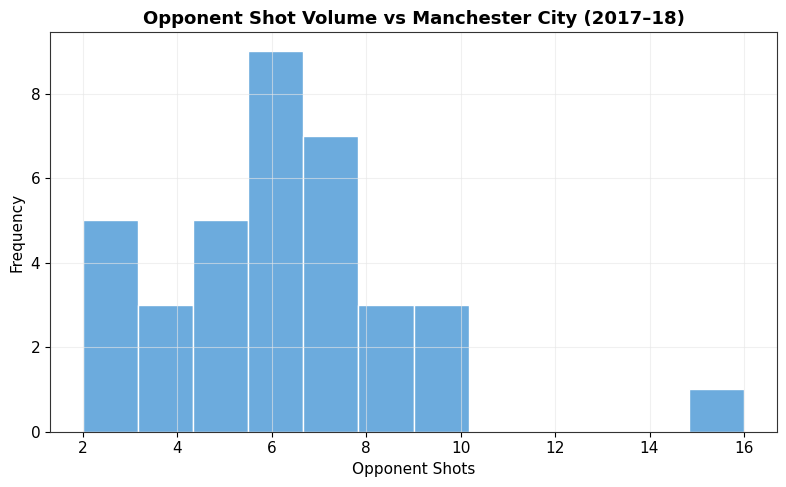

In [17]:
plt.figure(figsize=(8,5))
plt.hist(
    opp_shots_per_match,
    bins=12,
    color=CITY_BLUE,
    edgecolor="white"
)
plt.tight_layout()

plt.title(
    "Opponent Shot Volume vs Manchester City (2017–18)",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Opponent Shots")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Distribution Insight:**

Opponent shot volume appears left-skewed.

Most matches fall within 5-8 opponent shots.

**Interpretation:**

This establishes the defensive pressure environment Manchester City faced during the season.

In [18]:
print(df_block_a['result'].value_counts(normalize=True))

result
Missed Shot     0.382883
Saved Shot      0.252252
Blocked Shot    0.234234
Goal            0.108108
Shot On Post    0.013514
Own Goal        0.009009
Name: proportion, dtype: float64


## Opponent Shot Outcome Distribution

**Outcome Breakdown (%):**

- Saved Shots: 25.23%
- Blocked Shots: 23.42%
- Goals: 10.81%
- Shots Hit Woodwork: 1.35%
- Own Goals: 0.90%
- Missed Shots: 38.29%

**Interpretation:**

The majority of opponent attempts failed to reach the target (missed or blocked), suggesting that Manchester City’s defensive structure effectively suppressed shot quality.

In [19]:
shots_faced_mask = (
    (
        (df['team'] != 'Manchester City') &
        (df['result'].isin(['Saved Shot', 'Goal']))
    ) |
    (
        (df['team'] == 'Manchester City') &
        (df['result'] == 'Own Goal')
    )
) & (
    df['minute'].notna() &
    df['ederson_minutes'].notna() &
    (df['minute'] <= df['ederson_minutes'])
)

df_faced = df[shots_faced_mask].copy()

In [20]:
df_faced['result'].value_counts()

result
Saved Shot    51
Goal          22
Own Goal       2
Name: count, dtype: int64

In [21]:
shots_faced_per_match = (
    df_faced
    .groupby('game_id')
    .size()
)

shots_faced_per_match.describe()

count    29.000000
mean      2.586207
std       1.500410
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       7.000000
dtype: float64

In [22]:
total_matches = df['game_id'].nunique()
matches_with_shots = shots_faced_per_match.count()
zero_shot_matches = total_matches - matches_with_shots

total_matches, matches_with_shots, zero_shot_matches

(36, np.int64(29), np.int64(7))

**Zero-Shot Matches**

A subset of matches featured no shots on target against Manchester City while Ederson was on the pitch. These matches are analytically important because they reduce exposure volume and increase the leverage of the first shot faced in matches where shots do occur.

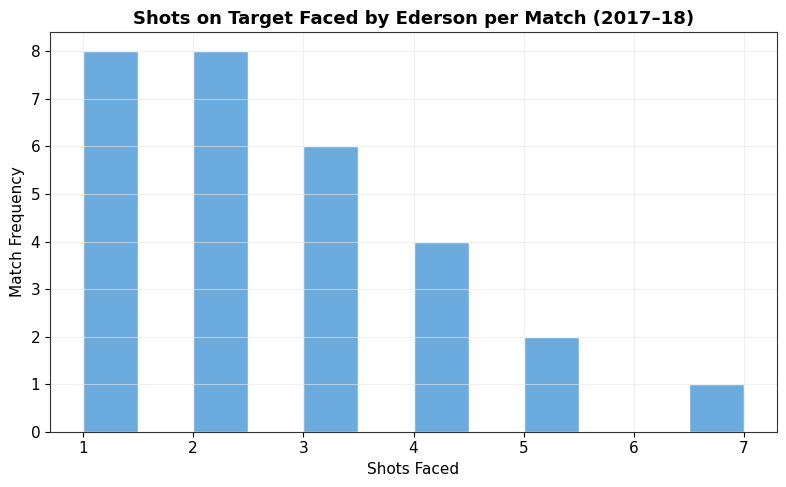

In [23]:
plt.figure(figsize=(8,5))

plt.hist(
    shots_faced_per_match,
    bins=12,
    color=CITY_BLUE,
    edgecolor="white"
)

plt.title(
    "Shots on Target Faced by Ederson per Match (2017–18)",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Shots Faced")
plt.ylabel("Match Frequency")

plt.tight_layout()
plt.show()

## Shots on Target Faced by Ederson

This section isolates goalkeeper-relevant events (opponent shots on target and own goals) that occurred while Ederson was on the pitch.

**Summary Statistics:**

- Total matches analyzed: **36**
- Matches with ≥1 shot on target faced: **29**
- Matches with zero shots on target faced: **7**
- Average shots faced (conditional on ≥1): **2.59 shots**
- Minimum shots faced: **1 shot**
- Maximum shots faced: **7 shots**

**Distribution Insight:**

The distribution of shots on target faced per match is moderately right-skewed, with most matches falling between **1–3 shots faced**.

**Interpretation:**

Ederson typically faced a low on-target workload per match, reflecting Manchester City’s strong territorial control during the 2017–18 Premier League season. Notably, several matches featured **zero shots on target faced**, highlighting the team’s defensive dominance and the relatively low exposure environment for the goalkeeper.

In [24]:
df_faced['result'].value_counts(normalize=True)

result
Saved Shot    0.680000
Goal          0.293333
Own Goal      0.026667
Name: proportion, dtype: float64

### Shot Outcome Distribution (Faced Shots)

**Outcome Breakdown (%):**

- Saved Shots: **68.0%**
- Goals: **29.3%**
- Own Goals: **2.7%**

**Interpretation:**

Among shots on target faced while Ederson was on the pitch, approximately **68% were saved**, while roughly **29% resulted in goals**. This establishes the baseline concession environment prior to isolating first-shot events and provides context for evaluating goalkeeper performance under limited but high-leverage exposure.

Having established Ederson’s overall shot exposure and outcome profile, the next section isolates first-shot events at the match level.

In [25]:
df_faced_sorted = (
    df_faced
    .sort_values(['game_id', 'minute'])
)

In [26]:
first_shots = (
    df_faced_sorted
    .groupby('game_id')
    .first()
    .reset_index()
)

first_shots.head()

,game_id,league,season,game,team,player,league_id,season_id,date,shot_id,...,assist_player_id,assist_player,xg,location_x,location_y,minute,body_part,situation,result,ederson_minutes
0,7126,ENG-Premier League,1718,2017-08-12 Brighton-Manchester City,Brighton,Lewis Dunk,1,2017,2017-08-12 17:30:00,158173,...,175828.0,Pascal Groß,0.034634,0.907,0.557,44,Right Foot,Set Piece,Saved Shot,90
1,7138,ENG-Premier League,1718,2017-08-21 Manchester City-Everton,Everton,Wayne Rooney,1,2017,2017-08-21 20:00:00,158522,...,176228.0,Dominic Calvert-Lewin,0.460745,0.916,0.452,34,Left Foot,Open Play,Goal,90
2,7139,ENG-Premier League,1718,2017-08-26 Bournemouth-Manchester City,Bournemouth,Charlie Daniels,1,2017,2017-08-26 12:30:00,159184,...,176901.0,Andrew Surman,0.017740,0.878,0.806,12,Left Foot,Open Play,Goal,90
3,7149,ENG-Premier League,1718,2017-09-09 Manchester City-Liverpool,Liverpool,Roberto Firmino,1,2017,2017-09-09 12:30:00,159382,...,177137.0,Jordan Henderson,0.067057,0.964,0.614,14,Right Foot,Open Play,Saved Shot,45
4,7164,ENG-Premier League,1718,2017-09-16 Watford-Manchester City,Watford,Nathaniel Chalobah,1,2017,2017-09-16 15:00:00,158951,...,176624.0,José Holebas,0.053284,0.878,0.493,52,Right Foot,From Corner,Saved Shot,90


In [27]:
first_shots['first_shot_conceded'] = (
    first_shots['result'] == 'Goal'
).astype(int)

first_shots[['game_id', 'result', 'first_shot_conceded']].head()

,game_id,result,first_shot_conceded
0,7126,Saved Shot,0
1,7138,Goal,1
2,7139,Goal,1
3,7149,Saved Shot,0
4,7164,Saved Shot,0


In [28]:
first_shot_rate = first_shots['first_shot_conceded'].mean()

print(f"First-shot concession rate: {first_shot_rate:.3f}")

First-shot concession rate: 0.310


In [29]:
total_first_shots = len(first_shots)
conceded_first_shots = first_shots['first_shot_conceded'].sum()

print(f"Matches with ≥1 shot faced: {total_first_shots}")
print(f"Matches where first shot was conceded: {conceded_first_shots}")

Matches with ≥1 shot faced: 29
Matches where first shot was conceded: 9


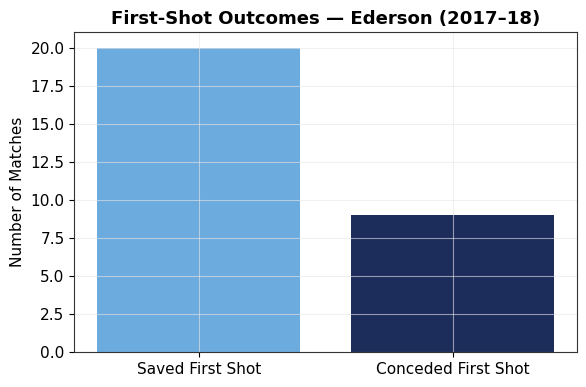

In [30]:
plt.figure(figsize=(6,4))

counts = first_shots['first_shot_conceded'].value_counts().sort_index()

plt.bar(
    ["Saved First Shot", "Conceded First Shot"],
    counts.values,
    color=[CITY_BLUE, CITY_DARK]
)

plt.title(
    "First-Shot Outcomes — Ederson (2017–18)",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

## First-Shot Concession Analysis

To evaluate early-match vulnerability, I isolated the first shot on target faced in each match and assessed whether it resulted in a goal.

**Results**

- Matches with ≥1 shot faced: **29**
- Matches where first shot resulted in a goal: **9**
- First-shot concession rate: **31.0%**

**Interpretation**

Ederson conceded on the first shot on target in approximately one-third of matches where he faced at least one shot. Given Manchester City’s generally low defensive exposure during the 2017–18 season, first-shot events represent high-leverage moments. This reinforces the importance of evaluating goalkeeper performance not only by aggregate save percentage but also by early-match resilience.

In [31]:
# Matches where Ederson conceded at least one goal
matches_with_goal = (
    df_faced[df_faced['result'] == 'Goal']
    .groupby('game_id')
    .size()
)

num_matches_with_goal = matches_with_goal.shape[0]

print(f"Matches with ≥1 goal conceded: {num_matches_with_goal}")

Matches with ≥1 goal conceded: 17


In [32]:
first_goal_share = conceded_first_shots / num_matches_with_goal

print(f"Share of conceded matches where first shot was the goal: {first_goal_share:.3f}")

Share of conceded matches where first shot was the goal: 0.529


### Timing of Goals Conceded

To further contextualize early-match vulnerability, I examined matches in which Ederson conceded at least once and evaluated how frequently the first shot on target accounted for the goal.

**Results**

- Matches with ≥1 goal conceded: 17
- Matches where the first shot was the goal: 9
- Share of conceded matches where goal came first: 52.9%

**Interpretation**

This conditional view isolates the timing of goals conceded. A high value indicates that when Manchester City did concede, it often occurred immediately upon the first shot on target, highlighting the high leverage of early defensive breakdowns in otherwise low-exposure matches.